<a href="https://colab.research.google.com/github/jgybels/CEE-593---Module-4/blob/main/Module_5_Advanced_Plane_and_Spatial_Sliding_in_Rock_Mass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5: Advanced Plane and Spatial Sliding in Rock Mass

## Introduction
The following notebook builds on the concepts from the eight referenced textbook pages.  
These sections expand on the physics of **plane sliding in rock mass**, examining situations where the sliding surface is constrained by joint sets (Figs. 10.39, 10.40, 10.41) and exploring **spatial (wedge) sliding** where two discontinuities intersect (Figs. 10.45, 10.46). There is also emphasis on **joint water pressure** (Figs. 10.42, 10.47), which can significantly reduce stability if water accumulates in discontinuities.

In this assignment, you will write and modify Python code to handle:
1. Plane sliding blocks with varying inclination, friction angles, and partial/ full joint water pressures.
2. A simplified approach to wedge (spatial) sliding when two intersecting planes daylights the slope.
3. Sensitivity analysis to see how joint water pressure, block geometry, or friction angles affect stability.

You are not expected to provide a complete solution for each item, but rather to create well-structured code and clear explanations, demonstrating how you integrate the theoretical equations with computational approaches. Focus on how changes in input parameters alter the factor of safety and interpret your results with reference to the textbook figures and concepts.



In [13]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

# Optional: set up a random seed for reproducibility if needed
np.random.seed(42)




## Part 1: Plane Sliding in Rock Mass

Recall from the textbook (Figs. 10.39–10.41) that a plane sliding mechanism in rock mass differs from sliding in soil because:
- The dip of the potential sliding plane is **flatter** than the slope (kinematic condition).
- The frictional resistance along this discontinuity is **overcome** (mechanical condition).

In a simple model, we treat the block as resting on a plane with friction angle φ. If the dip angle of that plane is θ and the slope angle is β, once θ (or a combination of angles) exceeds the maximum mobilized friction angle φ<sub>m</sub>, sliding can occur.

### Task
1. Define a Python function to compute a factor of safety for a single rock block on a plane with joint water pressure.  
2. Incorporate user-defined parameters:
   - Weight of the block.
   - Dip angle of the sliding plane (θ).
   - Joint water pressure ratio, or partial/ full water pressure assumption along the plane (refer to Figs. 10.42, 10.47).
   - Friction angle of the discontinuity (φ).
3. Provide helpful docstrings and brief commentary in your code.  
4. Run a quick test with some example values, verifying that your function behaves as expected.

Below is a skeleton code cell that you may modify. The actual formula for factor of safety should reference the polygon of forces approach described in the text. For instance, if the block weight is W, friction angle is φ, and the normal force is decreased by a water pressure W<sub>j</sub>, then:

**Effective Normal** = N<sub>eff</sub> = W cos(θ) - W<sub>j</sub>  
**Driving** = W sin(θ)  
**Resisting** = N<sub>eff</sub> tan(φ) (assuming no cohesion)

This is just an example. Expand or adjust to reflect the correct geometry from the textbook.


In [14]:
# Part 1: Plane Sliding Function (with joint water pressure)

"""
   Parameters:
    W  : Weight of the block (kN)
    theta_deg : Dip angle of the sliding plane (degrees)
    phi_deg   : Friction angle (degrees)
    water_pressure_ratio : Fraction of normal force replaced by water (0.0 means no water pressure)
    Cohesion = 0
"""
def plane_sliding_fos_rock(W, theta_deg, phi_deg, water_pressure_ratio=0.0):

    # Convert degrees to radians
    theta = np.radians(theta_deg)
    phi = np.radians(phi_deg)

    # Normal force without water
    N = W * np.cos(theta)
    # Driving force (Neff tan(φ)
    D = W * np.sin(theta)

    # Effective normal (Neff = W cos(θ) - Wj)
    N_eff = N * (1 - water_pressure_ratio)

    # If no normal force or negative, the block may be floating or unstable
    if N_eff <= 0:
        return 0.0

    # Resisting force from friction (R=Neff​tan(ϕ))
    R = N_eff * np.tan(phi)

    # Factor of safety (FS = R/D)
    if D == 0:
        return np.inf
    return R / D

# Test Scenario
example_W = 100.0          # kN
example_theta = 45.0       # deg
example_phi = 30.0         # deg
example_ratio = 0.3        # 30% water pressure ratio

print(f"Input parameters:")
print(f"  Block weight, W = {example_W:.1f} kN")
print(f"  Plane dip, theta = {example_theta:.1f} degrees")
print(f"  Friction angle, phi = {example_phi:.1f} degrees")
print(f"  Water pressure ratio = {example_ratio:.2f}")

fos_rock_example = plane_sliding_fos_rock(example_W, example_theta, example_phi, example_ratio)

print("Result:")
print(f"Factor of Safety = {fos_rock_example:.3f}")


Input parameters:
  Block weight, W = 100.0 kN
  Plane dip, theta = 45.0 degrees
  Friction angle, phi = 30.0 degrees
  Water pressure ratio = 0.30
Result:
Factor of Safety = 0.404


# Written Response
This function implements a simplified limit equilibrium approach for plane sliding, where stability is governed by the balance between driving forces and frictional resistance along a discontinuity, with water pressure reducing effective normal stress as shown in Figures 10.42.


## Part 2: Spatial (Wedge) Sliding

In Figs. 10.45–10.47, the textbook introduces a more three-dimensional problem where two discontinuities (joint planes) intersect. The line of intersection daylights out of the slope, and if both friction angles are exceeded, the block can slip along both planes simultaneously.

### Task
1. Implement a function that models wedge sliding.
2. Assume two planes with friction angles φ<sub>A</sub> and φ<sub>B</sub>, dips ω<sub>A</sub> and ω<sub>B</sub>.
3. Incorporate some form of joint water pressure if applicable (a simplified approach is fine).
4. Provide at least one test scenario to check if your wedge remains stable or fails.

Below is a code cell you can adapt. The main equations are summarized in the text (e.g., N<sub>A</sub> tan(φ<sub>A</sub>) + N<sub>B</sub> tan(φ<sub>B</sub>) must exceed driving forces along each plane). If you prefer the polygon of forces or the Schmidt net approach, you can approximate or simplify it here for demonstration.


In [26]:
# Part 2: Wedge (Spatial) Sliding
def wedge_sliding_fos(W, phiA_deg, phiB_deg, dipA_deg, dipB_deg,
                      intersection_dip_deg, water_pressure_ratio=0.0):
    """
    Estimate a simplified factor of safety for a wedge defined by two planes A and B.

    Parameters
    ----------
    W : float
        Weight of the wedge (kN)
    phiA_deg, phiB_deg : float
        Friction angles on planes A and B (degrees)
    dipA_deg, dipB_deg : float
        Dips of planes A and B (degrees)
    intersection_dip_deg : float
        Dip of the line of intersection (degrees)
    water_pressure_ratio : float, optional
        Approximate fraction that reduces normal forces on each plane

    Returns
    -------
    float
        Approximate factor of safety for the wedge
    """

    # Convert degrees to radians
    phiA = np.radians(phiA_deg)
    phiB = np.radians(phiB_deg)
    dipA = np.radians(dipA_deg)
    dipB = np.radians(dipB_deg)
    dipI = np.radians(intersection_dip_deg)

    # Approximate normal force on planes A and B
    # Half the wedge weight is carried by each plane
    NA = (W / 2.0) * np.cos(dipA) * (1 - water_pressure_ratio)
    NB = (W / 2.0) * np.cos(dipB) * (1 - water_pressure_ratio)

    # Driving force along the line of intersection
    D = W * np.sin(dipI)

    # Resisting force on each plane: R = N tan(phi)
    RA = NA * np.tan(phiA)
    RB = NB * np.tan(phiB)

    # Combined resisting force
    R_total = RA + RB

    if np.isclose(D, 0.0):
        return np.inf

    # Factor of safety
    return R_total / D


# Test scenario
fos_wedge_test = wedge_sliding_fos(
    W=100.0,
    phiA_deg=35.0,
    phiB_deg=30.0,
    dipA_deg=40.0,
    dipB_deg=35.0,
    intersection_dip_deg=20.0,
    water_pressure_ratio=0.2
)

print(f"Example Wedge FOS: {fos_wedge_test:.3f}")

if fos_wedge_test > 1:
    print("Interpretation: The wedge is stable in this test scenario.")
else:
    print("Interpretation: The wedge is unstable in this test scenario.")


Example Wedge FOS: 1.180
Interpretation: The wedge is stable in this test scenario.


# Written Response

This simplified wedge model captures the key concept that stability is controlled by the balance between the driving force along the line of intersection and the combined frictional resistance on both discontinuity planes, as illustrated in Figures 10.46 and 10.47.


## Part 3: Sensitivity Analysis

Now that you have basic functions for both plane and wedge/sliding blocks in rock masses, conduct a sensitivity study. For instance, you can vary:

- Friction angles (φ) across a range.
- Joint water pressure ratio from 0 to 0.5 or beyond.
- Intersection dips or plane dips in a wedge scenario.

Then plot the factor of safety against these parameters, just as you did in prior assignments for slope angle. Discuss how water pressure quickly undermines stability, or how certain dip angles lead to abrupt shifts from stable to unstable conditions.

### Task
1. Choose one of your function-based models (plane sliding or wedge).
2. Generate a sequence of parameter values (e.g., friction angles from 20° to 45°, or water pressure ratio from 0 to 0.5).
3. Compute factor of safety for each increment.
4. Produce a plot with appropriate labels and a reference line for FOS = 1.0.
5. Discuss your observations briefly in a separate Markdown cell.


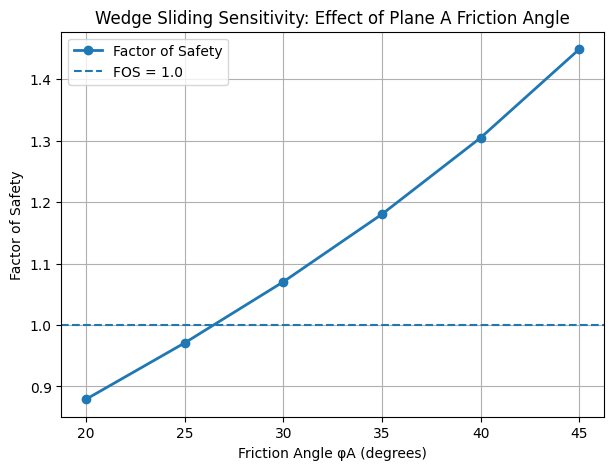

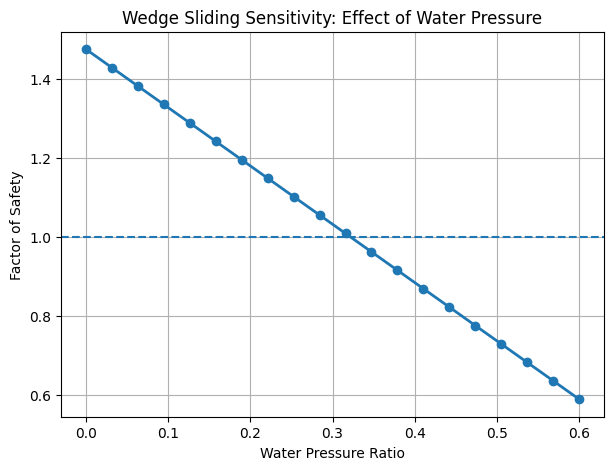

In [28]:
# Part 3: Sensitivity Analysis

# Wedge sliding sensitivity analalysis

def sensitivity_wedge_sliding():
    """
    Vary the friction angle on plane A and plot the resulting factor of safety.
    This function works whether wedge_sliding_fos returns a float or a dictionary.
    """

    # Range of friction angles to test
    friction_values = np.arange(20, 46, 5)
    fos_results = []

    # Fixed parameters for the sensitivity study
    W = 100.0
    phiB = 30.0
    dipA = 40.0
    dipB = 35.0
    intersection_dip = 20.0
    water_ratio = 0.2

    # Compute factor of safety for each friction angle
    for phiA_deg in friction_values:
        result = wedge_sliding_fos(
            W=W,
            phiA_deg=phiA_deg,
            phiB_deg=phiB,
            dipA_deg=dipA,
            dipB_deg=dipB,
            intersection_dip_deg=intersection_dip,
            water_pressure_ratio=water_ratio
        )

        # Support either a float return or a dictionary return
        fs = result["FS"] if isinstance(result, dict) else result
        fos_results.append(fs)

    # Plot results
    plt.figure(figsize=(7, 5))
    plt.plot(friction_values, fos_results, marker='o', linewidth=2, label="Factor of Safety")
    plt.axhline(y=1.0, linestyle='--', linewidth=1.5, label="FOS = 1.0")

    plt.title("Wedge Sliding Sensitivity: Effect of Plane A Friction Angle")
    plt.xlabel("Friction Angle φA (degrees)")
    plt.ylabel("Factor of Safety")
    plt.grid(True)
    plt.legend()
    plt.show()

# Execute the sensitivity analysis
sensitivity_wedge_sliding()

# Sensitivity check for water pressure ratio
def sensitivity_water_pressure():

    water_values = np.linspace(0.0, 0.6, 20)
    fos_results = []

    for ru in water_values:
        result = wedge_sliding_fos(
            W=100.0,
            phiA_deg=35.0,
            phiB_deg=30.0,
            dipA_deg=40.0,
            dipB_deg=35.0,
            intersection_dip_deg=20.0,
            water_pressure_ratio=ru
        )

        fs = result["FS"] if isinstance(result, dict) else result
        fos_results.append(fs)

    plt.figure(figsize=(7,5))
    plt.plot(water_values, fos_results, marker='o', linewidth=2)
    plt.axhline(1.0, linestyle='--', linewidth=1.5)

    plt.title("Wedge Sliding Sensitivity: Effect of Water Pressure")
    plt.xlabel("Water Pressure Ratio")
    plt.ylabel("Factor of Safety")
    plt.grid(True)
    plt.show()

# Run it
sensitivity_water_pressure()


# Written Response

The first sensitivity plot shows that the factor of safety increases as the friction angle on plane A increases. This is expected because a larger friction angle increases the frictional resistance available along that discontinuity.

The second sensitivity plot shows that the factor of safety decreases as water pressure ratio increases. This occurs because water pressure reduces the effective normal force acting on the planes, which lowers frictional resistance.


## Submission Instructions

1. Ensure each part of your notebook is clearly labeled:
   - Plane Sliding in Rock Mass (Part 1)
   - Spatial (Wedge) Sliding (Part 2)
   - Sensitivity Analysis (Part 3)
2. Provide inline comments or Markdown explanations referencing relevant figures (10.39–10.50) and any equations from the text.
3. Summarize your key findings at the end. Discuss where your simplified assumptions might differ from real field conditions (e.g., partial joint persistence, rock bridges, uneven water pressure).
4. Upload your completed notebook (including all code cells, Markdown documentation, and plots) to the designated course platform.

Remember, the code sketches here are only examples to get you started. You may refine, add more parameters, or introduce advanced geometry to match the complexity you feel is necessary for your analysis.

End of Assignment
